<a href="https://colab.research.google.com/github/lmf55/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/Atividade%20Aula%202.7/Atividade_Aula_2_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear com PyTorch - House Sales Prediction

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [44]:
%matplotlib inline
import torch
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [45]:
# Download do dataset House Sales Prediction do Kaggle
!curl -L -o /content/house-sales.zip https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0   389k      0  0:00:02  0:00:02 --:--:--  938k


In [46]:
!unzip -o /content/house-sales.zip

Archive:  /content/house-sales.zip
  inflating: kc_house_data.csv       


In [47]:
# Leitura do dataset
df = pd.read_csv('kc_house_data.csv')

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [48]:
df.shape

(21613, 21)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [50]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


### Seleção das variáveis

In [51]:
# Removendo colunas que não serão utilizadas no modelo inicial
df_model = df.drop(columns=['id', 'date', 'zipcode'])

In [52]:
# Variável alvo
y = df_model[['price']].values

# Variáveis de entrada
X = df_model.drop(columns=['price']).values

### Normalização dos dados

In [53]:
# Normalização das entradas
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalização da saída
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [54]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 17])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 17])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [55]:
# Número de variáveis de entrada do dataset de casas
n_features = X_train_tensor.shape[1]

# Modelo de regressão linear múltipla
model = torch.nn.Linear(n_features, 1)

model

Linear(in_features=17, out_features=1, bias=True)

### Verificando a inicialização dos parâmetros

In [56]:
model.weight.data

tensor([[-0.2285, -0.0476, -0.1165, -0.0647, -0.2143,  0.0973, -0.2174, -0.0155,
          0.0843, -0.0818,  0.1376,  0.0306,  0.1333,  0.1556, -0.1071,  0.0881,
         -0.1049]])

### Testando o predict da rede

In [57]:
model(torch.ones(5, n_features))

tensor([[-0.3952],
        [-0.3952],
        [-0.3952],
        [-0.3952],
        [-0.3952]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [58]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

### Laço de treinamento

In [59]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [60]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [61]:
num_epochs = 300

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # Treino
    train_loss = train_epoch(
        model,
        optimizer,
        criterion,
        X_train_tensor,
        y_train_tensor
    )

    train_losses.append(train_loss)

    # Validação
    val_loss = validate_epoch(
        model,
        criterion,
        X_val_tensor,
        y_val_tensor
    )

    val_losses.append(val_loss)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[50/300], Train Loss: 0.343481, Val Loss: 0.373758
Epoch[100/300], Train Loss: 0.313599, Val Loss: 0.342015
Epoch[150/300], Train Loss: 0.303929, Val Loss: 0.332556
Epoch[200/300], Train Loss: 0.299827, Val Loss: 0.329059
Epoch[250/300], Train Loss: 0.297806, Val Loss: 0.327633
Epoch[300/300], Train Loss: 0.296721, Val Loss: 0.327039


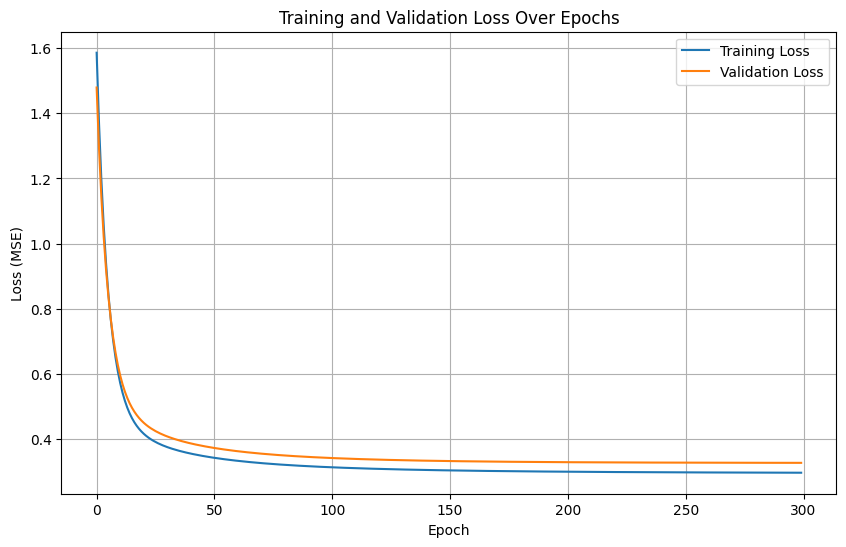

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

Durante o treinamento, acompanhamos a perda no conjunto de treino e no conjunto de validação.

A perda de treino mostra o quanto o modelo está aprendendo com os dados usados no ajuste.

A perda de validação indica como o modelo se comporta em dados que não foram usados diretamente para atualizar os pesos.

## Avaliação

In [63]:
model.eval()

with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_val = model(X_val_tensor)

train_mse = criterion(y_pred_train, y_train_tensor)
val_mse = criterion(y_pred_val, y_val_tensor)

print("MSE final no treino:", train_mse.item())
print("MSE final na validação:", val_mse.item())

MSE final no treino: 0.29670482873916626
MSE final na validação: 0.32703933119773865


In [64]:
# Convertendo os valores reais e preditos para a escala original de preço

y_val_real = y_scaler.inverse_transform(y_val_tensor.numpy())
y_pred_real = y_scaler.inverse_transform(y_pred_val.numpy())

y_train_real = y_scaler.inverse_transform(y_train_tensor.numpy())
y_pred_train_real = y_scaler.inverse_transform(y_pred_train.numpy())

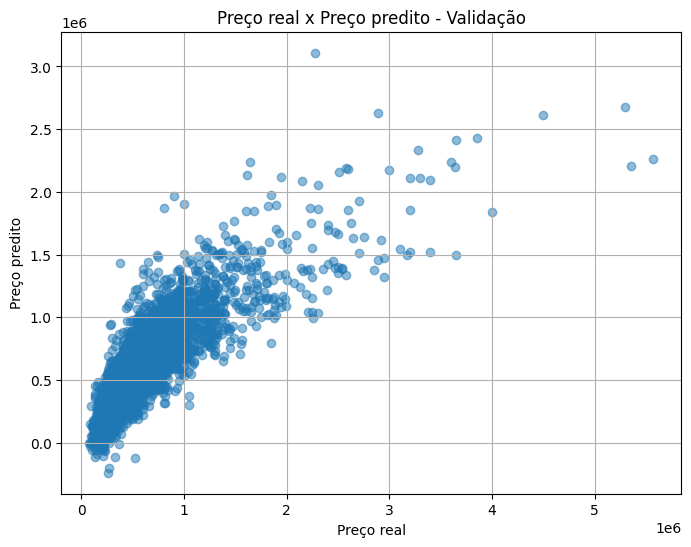

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val_real, y_pred_real, alpha=0.5)

plt.xlabel('Preço real')
plt.ylabel('Preço predito')
plt.title('Preço real x Preço predito - Validação')
plt.grid(True)
plt.show()

Este gráfico compara o preço real com o preço previsto pelo modelo.
Quanto mais próximos os pontos estiverem de uma linha diagonal imaginária, melhor está o desempenho da regressão.

Pontos muito afastados indicam casas em que o modelo errou mais a previsão.

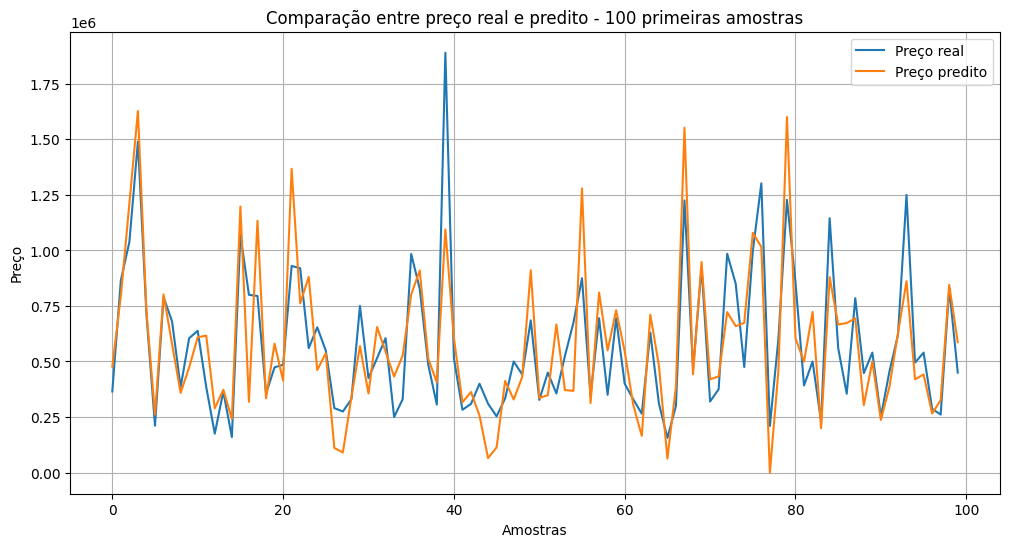

In [66]:
plt.figure(figsize=(12, 6))

plt.plot(y_val_real[:100], label='Preço real')
plt.plot(y_pred_real[:100], label='Preço predito')

plt.xlabel('Amostras')
plt.ylabel('Preço')
plt.title('Comparação entre preço real e predito - 100 primeiras amostras')
plt.legend()
plt.grid(True)
plt.show()

Este gráfico mostra a comparação entre os preços reais e preditos nas 100 primeiras amostras do conjunto de validação.

Ele facilita a visualização da proximidade entre a previsão do modelo e o valor real observado.

In [67]:
mae = np.mean(np.abs(y_val_real - y_pred_real))
rmse = np.sqrt(np.mean((y_val_real - y_pred_real) ** 2))

print("MAE na validação:", mae)
print("RMSE na validação:", rmse)

MAE na validação: 127922.48
RMSE na validação: 209945.47


O MAE representa o erro absoluto médio em dólares.
O RMSE também mede o erro em dólares, mas penaliza mais fortemente erros grandes.

Essas métricas ajudam a interpretar o desempenho do modelo na escala real do problema de previsão de preço de casas.

###Conclusão
Nesta atividade, adaptamos o modelo de regressão linear do dataset Salary para o dataset House Sales Prediction.

Diferente do exemplo original, este problema utiliza múltiplas variáveis de entrada para prever o preço das casas.

O modelo foi treinado com PyTorch usando nn.Linear, MSELoss e o otimizador SGD.

A normalização foi importante para estabilizar o treinamento, já que as variáveis do dataset possuem escalas muito diferentes.

Pelos gráficos e métricas, o modelo consegue capturar parte da tendência dos preços, mas uma regressão linear simples possui limitações para representar toda a complexidade do mercado imobiliário.